## Linear Regression

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv("tvmarketing.csv")
df.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


In [3]:
# describe the dataset
df.describe()

,TV,Sales
count,200.000000,200.000000
mean,147.042500,14.022500
std,85.854236,5.217457
min,0.700000,1.600000
25%,74.375000,10.375000
50%,149.750000,12.900000
75%,218.825000,17.400000
max,296.400000,27.000000


In [4]:
# Missing Value Check
df.isnull().sum()

TV       0
Sales    0
dtype: int64

In [5]:
# separate the features as dataframes and target as series
X=df.iloc[:,:-1]  # all columns except the last one (Features)
y=df.iloc[:,-1]   # only the last column (Target)

print(X)
print(y)

        TV
0    230.1
1     44.5
2     17.2
3    151.5
4    180.8
..     ...
195   38.2
196   94.2
197  177.0
198  283.6
199  232.1

[200 rows x 1 columns]
0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: Sales, Length: 200, dtype: float64


### Train-Test Split

In [6]:
# %pip install scikit-learn


In [7]:
from sklearn.model_selection import train_test_split

# Train-Test Split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (140, 1)
X_test shape: (60, 1)
y_train shape: (140,)
y_test shape: (60,)


##### Linear Regression

In [8]:
from sklearn.linear_model import LinearRegression

lin_reg=LinearRegression()
lin_reg.fit(X_train,y_train)

# Lets see the coefficients and intercept
print("Coefficients:", lin_reg.coef_)
print("Intercept:", lin_reg.intercept_) 


Coefficients: [0.0464078]
Intercept: 7.239459830751138


In [9]:
# Lets find the model prediction on the train data and the split data 
#We will use the predict function of the LinearRegression class

y_train_pred=lin_reg.predict(X_train)
y_test_pred=lin_reg.predict(X_test)


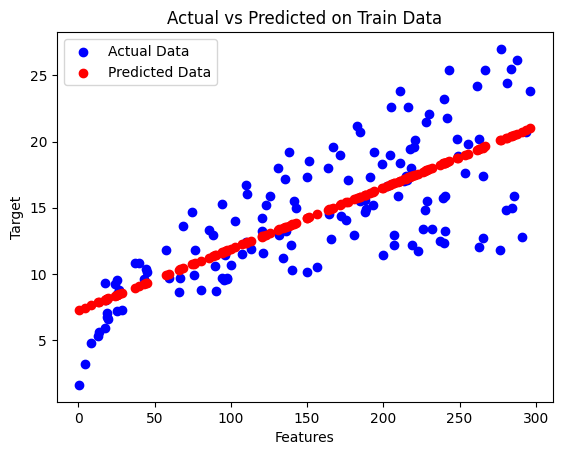

In [10]:
# Visualizing the data

plt.scatter(X_train, y_train, color='blue', label='Actual Data')
plt.scatter(X_train, y_train_pred, color='r', label='Predicted Data')
plt.title("Actual vs Predicted on Train Data")

plt.xlabel("Features")
plt.ylabel("Target")    
plt.legend()

plt.show()

### Lec 3

In [11]:
from sklearn.metrics import mean_squared_error,r2_score  #think of r2 as accuracy for now

In [12]:
mse_train=mean_squared_error(y_train,y_train_pred)  # Error between actual and predicted values on train data
mse_test=mean_squared_error(y_test,y_test_pred)  # Error between actual and predicted values on the test data

print("Mean Squared Error on Train Data:", mse_train)
print("Mean Squared Error on Test Data:", mse_test)


Mean Squared Error on Train Data: 11.189103289351676
Mean Squared Error on Test Data: 8.970991242413614


In [13]:
r2_train=r2_score(y_train,y_train_pred)  # Error between actual and predicted values on train data
r2_test=r2_score(y_test,y_test_pred)  # Error between actual and predicted values on the test data

print("R2 on Train Data:", r2_train)
print("R2 on Test Data:", r2_test)


# The accuracy is better on the test data than the training data

R2 on Train Data: 0.5736021199591975
R2 on Test Data: 0.6714477229302764


## Lec 4

#### Non Linear Regression   

In [ ]:
# Let us create polynomial features and see if we can improve the model

from sklearn.preprocessing import PolynomialFeatures
poly_features=PolynomialFeatures(degree=5)

x_train_poly=poly_features.fit_transform(X_train)  # Transforming the training data
x_test_poly=poly_features.transform(X_test)  # Transforming the test data
